In [1]:
import pennylane as qp
qml = qp
from pennylane import numpy as np

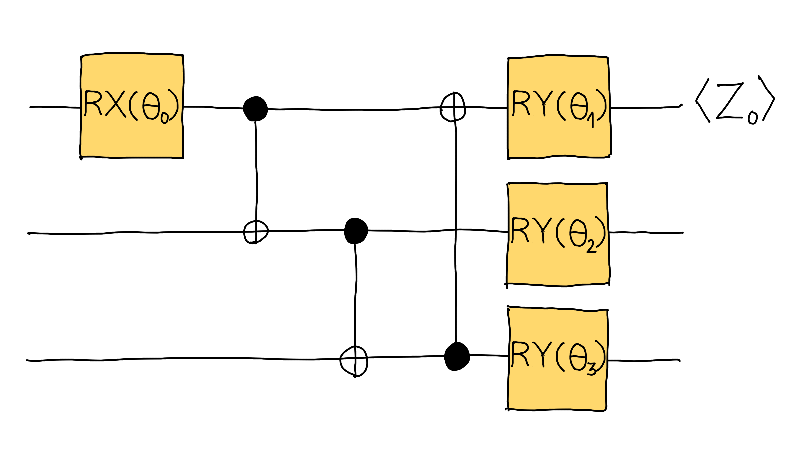

In [2]:
dev = qp.device("default.qubit", wires = 3)

@qp.qnode(dev)
def circuit_as_function(params):
    """
    Implements the circuit shown in the codercise statement.
    Args:
    - params (np.ndarray): [theta_0, theta_1, theta_2, theta_3]
    Returns:
    - (np.tensor): <Z0>
    """

    ####################
    ###YOUR CODE HERE###
    ####################
    qp.RX(params[0], wires=0)
    qp.CNOT(wires=[0, 1])
    qp.CNOT(wires=[1, 2])
    qp.CNOT(wires=[2, 0])
    qp.RY(params[1], wires=0)
    qp.RY(params[2], wires=1)
    qp.RY(params[3], wires=2)

    return qp.expval(qp.PauliZ(0)) # Return the expectation value

angles = np.linspace(0, 4 * np.pi, 200)
output_values = np.array([circuit_as_function([0.5, t, 0.5, 0.5]) for t in angles])

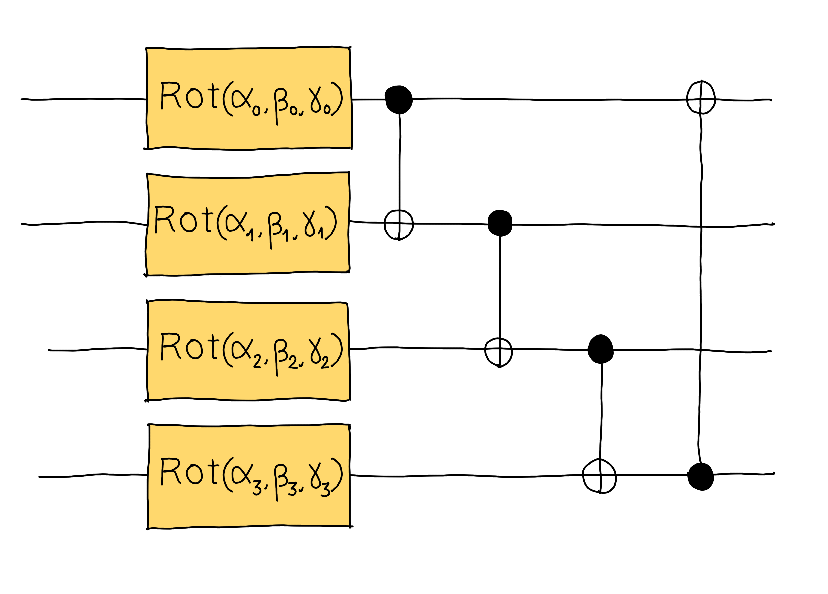

In [3]:
dev = qp.device("default.qubit", wires = 4)

@qp.qnode(dev)
def strong_entangler(weights):
    """
    Applies Strongly Entangling Layers to the default initial state
    Args:
    - weights (np.ndarray): The weights argument for qp.StronglyEntanglingLayers
    Returns:
    - (np.tensor): <Z0>
    """

    ####################
    ###YOUR CODE HERE###
    ####################
    qp.StronglyEntanglingLayers(weights=weights, wires=range(4))
    
    return qp.expval(qp.PauliZ(0))

shape = qp.StronglyEntanglingLayers.shape(n_layers=1, n_wires=4)
rng = np.random.default_rng(12345)
test_weights = rng.random(size=shape) # Write some valid weights here.
print(shape, test_weights)

print("The output of your circuit with these weights is: ", strong_entangler(test_weights))

(1, 4, 3) [[[0.22733602 0.31675834 0.79736546]
  [0.67625467 0.39110955 0.33281393]
  [0.59830875 0.18673419 0.67275604]
  [0.94180287 0.24824571 0.94888115]]]
The output of your circuit with these weights is:  0.8805676541576933


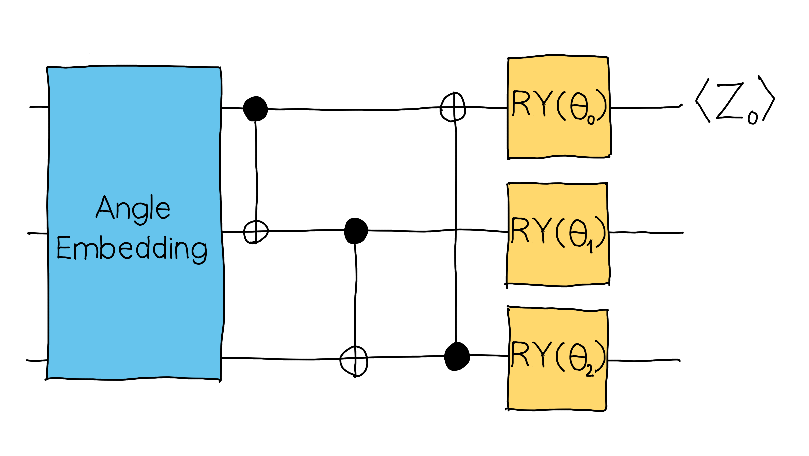

In [4]:
dev = qp.device("default.qubit", wires = 3)

@qp.qnode(dev)
def embedding_and_circuit(features, params):
    """
    A QNode that depends on trainable and non-trainable parameters
    Args:
    - features (np.ndarray): Non-trainable parameters in the AngleEmbedding routine
    - params (np.ndarray): Trainable parameters for the rest of the circuit
    Returns:
    - (np.tensor): <Z0>
    """

    ####################
    ###YOUR CODE HERE###
    ####################
    qp.AngleEmbedding(features=features, wires=range(3))
    qp.CNOT(wires=[0, 1])
    qp.CNOT(wires=[1, 2])
    qp.CNOT(wires=[2, 0])
    qp.RY(params[0], wires=0)
    qp.RY(params[1], wires=1)
    qp.RY(params[2], wires=2)
    
    return qp.expval(qp.PauliZ(0))

features = np.array([0.3,0.4,0.6], requires_grad = False)
params = np.array([0.4,0.7,0.9], requires_grad = True)
print("The gradient of the circuit is:", qp.jacobian(embedding_and_circuit)(features, params))

The gradient of the circuit is: [-2.96029765e-01  2.77555756e-17  0.00000000e+00]


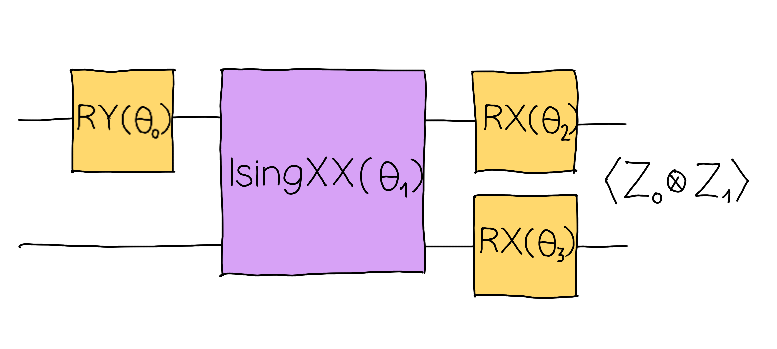

In [5]:
dev = qp.device("default.qubit", wires = 2)

@qp.qnode(dev, diff_method = "parameter-shift", max_diff = 2)
def circuit_for_hessian(params):
    """
    Implements the circuit shown in the codercise statement
    Args:
    - params (np.ndarray): [theta_0, theta_1, theta_2, theta_3]
    Returns:
    - np.tensor: <Z0xZ1>
    """

    ####################
    ###YOUR CODE HERE###
    ####################
    qp.RY(params[0], wires=0)
    qp.IsingXX(params[1], wires=[0, 1])
    qp.RX(params[2], wires=0)
    qp.RX(params[3], wires=1)

    return qp.expval(qp.PauliZ(0) @ qp.PauliZ(1)) # Return the expectation value required

test_params = np.array([0.1,0.2,0.3,0.4], requires_grad = True)
# Don't change test_params! 

hessian = qp.jacobian(qp.jacobian(circuit_for_hessian))(test_params) # Compute the Hessian
print("The hessian of the circuit is: \n", hessian)

The hessian of the circuit is: 
 [[-8.75527226e-01  2.81394209e-18  2.71738709e-02  3.71405819e-02]
 [ 0.00000000e+00 -2.22044605e-16  0.00000000e+00  0.00000000e+00]
 [ 2.71738709e-02  2.31285084e-18 -8.75527226e-01  1.14506063e-01]
 [ 3.71405819e-02  1.33412141e-17  1.14506063e-01 -8.75527226e-01]]


In [6]:
def cost_function(params):
    """
    Computes the cost function given in the codercise, as a function of the
    parameters of circuit_as_function.
    Args:
    - params (np.ndarray): The parameters we pass to circuit_as_function
    Returns:
    - np.float: The cost function evaluated in params.
    """
    ################
    #YOUR CODE HERE#
    ################
    x = circuit_as_function(params)

    return x**3 - (x**2)/2 + x # Return the value of the cost function